# Amazon India Sales Analysis - Complete Project Notebook
**Team:** Suraj Pamnani and teammate

This notebook runs the whole project in order. Run the cells top to bottom (Kernel > Restart & Run All).

| Step | Task |
|---|---|
| 1 | Setup and imports |
| 2 | Load the data |
| 3 | Inspect the data (shape, types, missing values) |
| 4 | Clean the data |
| 5 | Feature engineering |
| 6 | Exploratory data analysis (8 plots) |
| 7 | Statistical tests |
| 8 | Baseline machine learning model |
| 9 | Save results |

## Step 1 - Setup and imports

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 30)

# Notebooks run from the notebooks/ folder, so move to the project root
import os
if not Path("data/raw/amazon.csv").exists():
    os.chdir(Path.cwd().parent)
print("Working directory:", Path.cwd())

RAW = Path("data/raw/amazon.csv")
OUT_FIG = Path("reports/figures")
OUT_FIG.mkdir(parents=True, exist_ok=True)
Path("data/processed").mkdir(parents=True, exist_ok=True)

Working directory: /home/claude/proj


## Step 2 - Load the data

In [2]:
df = pd.read_csv(RAW)
print("Shape:", df.shape)
df.head(3)

Shape: (1465, 16)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...


## Step 3 - Inspect the data
Check data types, missing values and duplicates before changing anything.

In [3]:
print(df.dtypes, "\n")
print("Missing values:\n", df.isna().sum()[df.isna().sum() > 0], "\n")
print("Duplicate product_ids:", df["product_id"].duplicated().sum())
print("Non-numeric ratings:", df.loc[pd.to_numeric(df["rating"], errors="coerce").isna(), "rating"].tolist())

product_id             str
product_name           str
category               str
discounted_price       str
actual_price           str
discount_percentage    str
rating                 str
rating_count           str
about_product          str
user_id                str
user_name              str
review_id              str
review_title           str
review_content         str
img_link               str
product_link           str
dtype: object 

Missing values:
 rating_count    2
dtype: int64 

Duplicate product_ids: 114
Non-numeric ratings: ['|']


**Finding:** price, discount and rating_count are stored as text (e.g. `₹1,099`, `64%`, `24,269`). There are 2 missing rating_count values, 1 malformed rating (`|`) and 114 duplicate product ids.

## Step 4 - Clean the data

In [4]:
def to_number(s: pd.Series) -> pd.Series:
    """Remove rupee sign, commas and % then convert to float."""
    return pd.to_numeric(s.astype(str).str.replace(r"[₹,%]", "", regex=True).str.strip(), errors="coerce")

clean = df.copy()
for col in ["discounted_price", "actual_price", "discount_percentage", "rating_count"]:
    clean[col] = to_number(clean[col])
clean["rating"] = pd.to_numeric(clean["rating"], errors="coerce")

# Fill the few missing values with the median
clean["rating"] = clean["rating"].fillna(clean["rating"].median())
clean["rating_count"] = clean["rating_count"].fillna(clean["rating_count"].median())

# Drop duplicate products
before = len(clean)
clean = clean.drop_duplicates(subset="product_id").reset_index(drop=True)
print(f"Rows: {before} -> {len(clean)}")
clean[["discounted_price", "actual_price", "discount_percentage", "rating", "rating_count"]].describe().round(2)

Rows: 1465 -> 1351


,discounted_price,actual_price,discount_percentage,rating,rating_count
count,1351.00,1351.00,1351.00,1351.00,1351.00
mean,3304.80,5691.18,46.69,4.09,17626.04
std,7173.98,11218.67,21.63,0.30,42117.14
min,39.00,39.00,0.00,2.00,2.00
25%,349.00,899.00,31.00,3.90,1107.00
50%,899.00,1795.00,49.00,4.10,4740.00
75%,2174.00,4575.00,62.00,4.30,15995.00
max,77990.00,139900.00,94.00,5.00,426973.00


## Step 5 - Feature engineering

In [5]:
parts = clean["category"].str.split("|")
clean["main_category"] = parts.str[0].str.replace("&", " & ", regex=False)
clean["sub_category"] = parts.str[-1].str.replace("&", " & ", regex=False)
clean["discount_amount"] = clean["actual_price"] - clean["discounted_price"]
clean["log_rating_count"] = np.log1p(clean["rating_count"])
clean["price_band"] = pd.cut(
    clean["actual_price"],
    bins=[0, 500, 1000, 5000, 20000, np.inf],
    labels=["<500", "500-1K", "1K-5K", "5K-20K", ">20K"],
)
clean.to_csv("data/processed/amazon_clean.csv", index=False)
clean["main_category"].value_counts()

main_category
Electronics                490
Home & Kitchen             448
Computers & Accessories    375
OfficeProducts              31
MusicalInstruments           2
HomeImprovement              2
Toys & Games                 1
Car & Motorbike              1
Health & PersonalCare        1
Name: count, dtype: int64

## Step 6 - Exploratory data analysis
Each plot is saved to `reports/figures/` so it can go into the Word report.

In [6]:
NUM = ["discounted_price", "actual_price", "discount_percentage", "rating", "rating_count"]
TOP3 = ["Electronics", "Home & Kitchen", "Computers & Accessories"]
top = clean[clean["main_category"].isin(TOP3)]

def save(name):
    plt.tight_layout()
    plt.savefig(OUT_FIG / name, dpi=160)
    plt.show()

### Plot 1 - Rating distribution

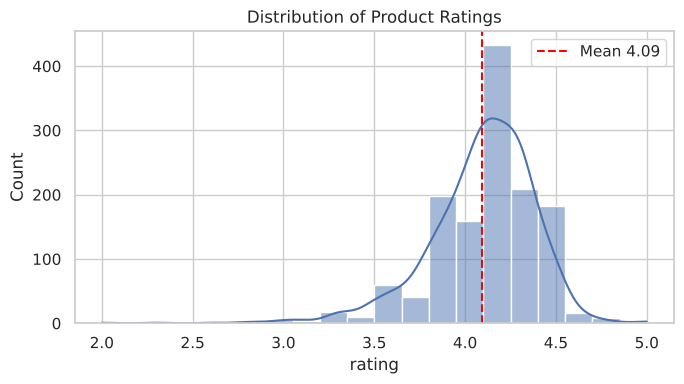

In [7]:
plt.figure(figsize=(7, 4))
sns.histplot(clean["rating"], bins=20, kde=True)
plt.axvline(clean["rating"].mean(), color="red", ls="--", label=f"Mean {clean['rating'].mean():.2f}")
plt.title("Distribution of Product Ratings"); plt.legend()
save("01_rating_distribution.png")

### Plot 2 - Discount distribution

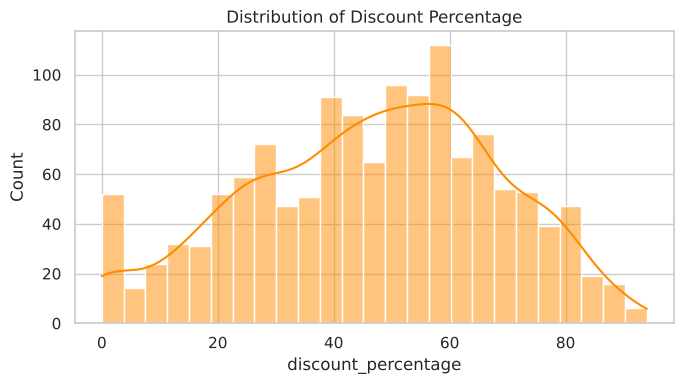

In [8]:
plt.figure(figsize=(7, 4))
sns.histplot(clean["discount_percentage"], bins=25, kde=True, color="darkorange")
plt.title("Distribution of Discount Percentage")
save("02_discount_distribution.png")

### Plot 3 - Products per category

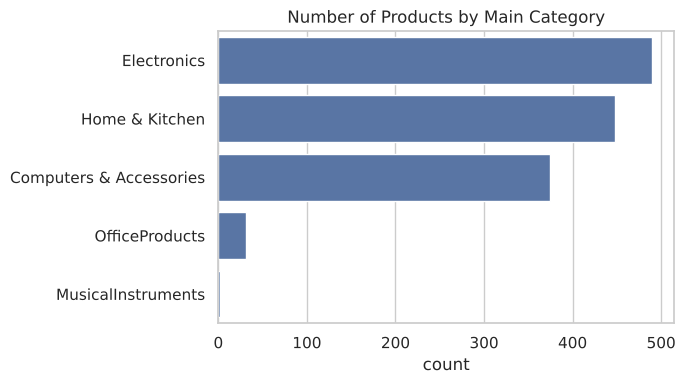

In [9]:
order = clean["main_category"].value_counts().index[:5]
plt.figure(figsize=(7, 4))
sns.countplot(data=clean[clean["main_category"].isin(order)], y="main_category", order=order)
plt.title("Number of Products by Main Category"); plt.ylabel("")
save("03_category_counts.png")

### Plot 4 - Correlation heatmap

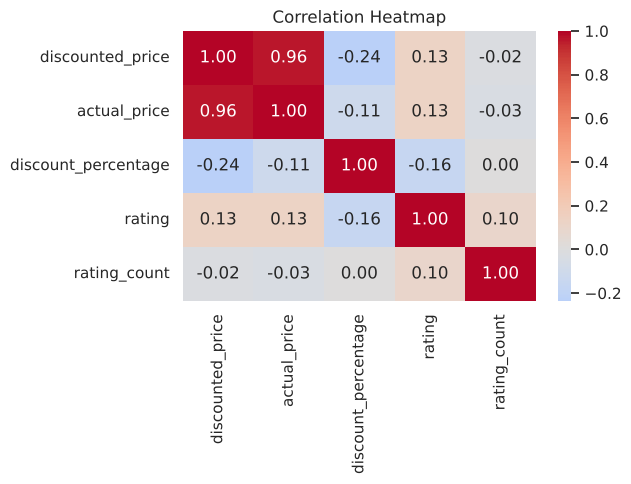

In [10]:
plt.figure(figsize=(6.5, 5))
sns.heatmap(clean[NUM].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
save("04_correlation_heatmap.png")

### Plot 5 - Discount by category (box plot)

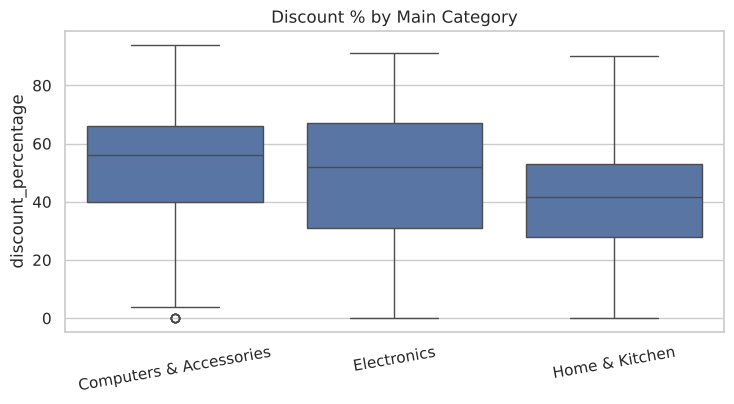

In [11]:
plt.figure(figsize=(7.5, 4.2))
sns.boxplot(data=top, x="main_category", y="discount_percentage")
plt.title("Discount % by Main Category"); plt.xlabel(""); plt.xticks(rotation=10)
save("05_discount_by_category.png")

### Plot 6 - Price vs rating (scatter)

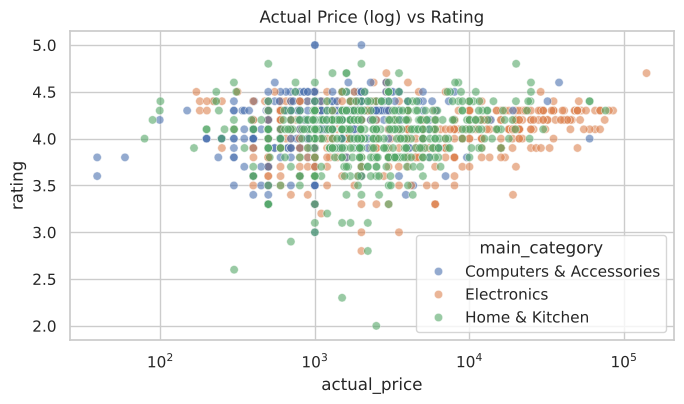

In [12]:
plt.figure(figsize=(7, 4.2))
sns.scatterplot(data=top, x="actual_price", y="rating", hue="main_category", alpha=0.6)
plt.xscale("log"); plt.title("Actual Price (log) vs Rating")
save("06_price_vs_rating.png")

### Plot 7 - Top sub-categories by engagement

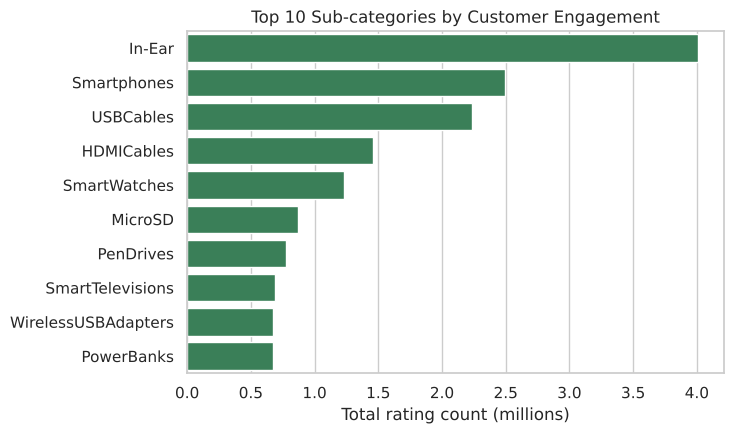

In [13]:
sub = clean.groupby("sub_category")["rating_count"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(7.5, 4.5))
sns.barplot(x=sub.values / 1e6, y=sub.index, color="seagreen")
plt.xlabel("Total rating count (millions)"); plt.ylabel("")
plt.title("Top 10 Sub-categories by Customer Engagement")
save("07_top_subcategories.png")

### Plot 8 - Discount and rating by price band

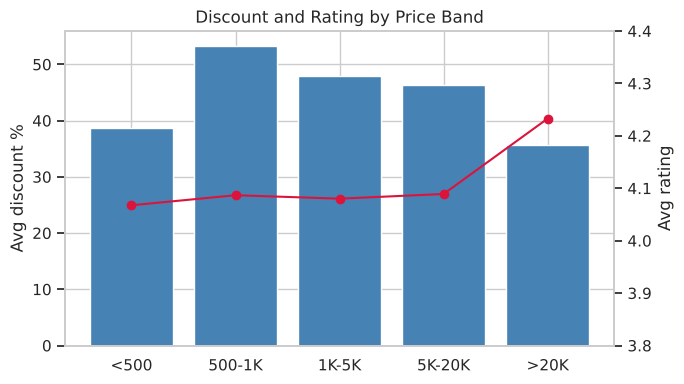

,discount_percentage,rating
price_band,,
<500,38.65,4.07
500-1K,53.27,4.09
1K-5K,47.94,4.08
5K-20K,46.30,4.09
>20K,35.65,4.23


In [14]:
band = clean.groupby("price_band", observed=True)[["discount_percentage", "rating"]].mean()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(band.index.astype(str), band["discount_percentage"], color="steelblue")
ax.set_ylabel("Avg discount %")
ax2 = ax.twinx()
ax2.plot(band.index.astype(str), band["rating"], color="crimson", marker="o")
ax2.set_ylabel("Avg rating"); ax2.set_ylim(3.8, 4.4); ax2.grid(False)
plt.title("Discount and Rating by Price Band")
save("08_price_band.png")
band.round(2)

## Step 7 - Statistical tests
The plots suggest some patterns. These tests check whether they are real or just noise.

In [15]:
# Test 1: is discount linked to rating? (Spearman, robust to outliers)
rho, p = stats.spearmanr(clean["discount_percentage"], clean["rating"])
print(f"Discount vs rating: rho={rho:.3f}, p={p:.4f}")

# Test 2: do the top 3 categories differ in discount? (Kruskal-Wallis)
groups = [g["discount_percentage"].values for _, g in top.groupby("main_category")]
h, p2 = stats.kruskal(*groups)
print(f"Discount across top-3 categories: H={h:.2f}, p={p2:.2e}")

# Test 3: do expensive products (>5000) get higher ratings? (Mann-Whitney)
exp = clean.loc[clean["actual_price"] > 5000, "rating"]
chp = clean.loc[clean["actual_price"] <= 5000, "rating"]
u, p3 = stats.mannwhitneyu(exp, chp, alternative="greater")
print(f"Expensive vs cheap rating: mean {exp.mean():.2f} vs {chp.mean():.2f}, p={p3:.4f}")

Discount vs rating: rho=-0.149, p=0.0000
Discount across top-3 categories: H=97.15, p=8.01e-22
Expensive vs cheap rating: mean 4.13 vs 4.08, p=0.0144


**How to read this:** a p-value below 0.05 means the pattern is unlikely to be chance.

## Step 8 - Baseline machine learning model
Goal: predict `rating` from price, discount, engagement and category.

In [16]:
features = ["discounted_price", "actual_price", "discount_percentage", "log_rating_count"]
X = pd.concat([clean[features], pd.get_dummies(clean["main_category"], drop_first=True)], axis=1)
y = clean["rating"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

baseline_mae = mean_absolute_error(y_test, np.full(len(y_test), y_train.mean()))
lr = LinearRegression().fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(X_train, y_train)

results = pd.DataFrame({
    "Model": ["Mean baseline", "Linear Regression", "Random Forest"],
    "R2": [0.0, r2_score(y_test, lr.predict(X_test)), r2_score(y_test, rf.predict(X_test))],
    "MAE": [baseline_mae, mean_absolute_error(y_test, lr.predict(X_test)), mean_absolute_error(y_test, rf.predict(X_test))],
}).round(3)
results

,Model,R2,MAE
0,Mean baseline,0.000,0.213
1,Linear Regression,0.103,0.200
2,Random Forest,0.034,0.198


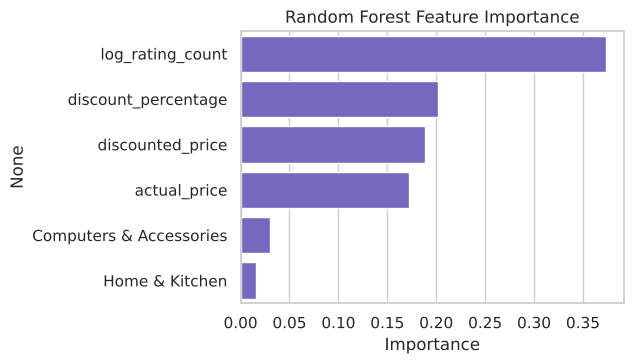

In [17]:
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(6)
plt.figure(figsize=(6.5, 3.8))
sns.barplot(x=importance.values, y=importance.index, color="slateblue")
plt.title("Random Forest Feature Importance"); plt.xlabel("Importance")
save("09_feature_importance.png")

**Conclusion:** both models only slightly beat the mean baseline, so price and discount alone cannot predict rating well. The next step is text analysis of `review_content`.

## Step 9 - Save results

In [18]:
metrics = {
    "n_products": int(len(clean)),
    "mean_rating": round(float(clean["rating"].mean()), 2),
    "median_discount": float(clean["discount_percentage"].median()),
    "models": results.to_dict(orient="records"),
}
Path("reports/metrics.json").write_text(json.dumps(metrics, indent=2))
print("Saved cleaned data, 9 figures and metrics.json")

Saved cleaned data, 9 figures and metrics.json
